# Assignment 3
## Exploratory Data Analysis: Titanic Dataset

**Yegor Gariazha**

**Dataset** Titanic — Machine Learning from Disaster   
**Source** https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv 

---

## Problem Definition  
The objective of this analysis is to evaluate and predict passenger survival during the RMS Titanic disaster. This problem matters because it allows us to examine historical data, identify which demographic factors (like age, gender, and ticket class) most heavily influenced survival rates, and build a predictive model based on these findings.

---
## 0. Setup & Imports


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

---
## 1. Dataset Description

The **Titanic dataset** contains information about 891 passengers aboard the RMS Titanicю



In [23]:
# ── Load dataset ───────────────────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df  = pd.read_csv(url)

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Shape: 891 rows × 12 columns


In [24]:
# ── Preview ────────────────────────────────────────────────────────────────
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
# ── Column overview ────────────────────────────────────────────────────────
print(f"\nNumber of Rows and Columns: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Number of Rows and Columns: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


### Column Descriptions

| Column | Type | Description |
|---|---|---|
| `PassengerId` | Numeric (ID) | Unique identifier for each passenger |
| `Survived` | Binary (0/1) | **Target variable** — 0 = did not survive, 1 = survived |
| `Pclass` | Ordinal (1/2/3) | Ticket class — 1st, 2nd, or 3rd |
| `Name` | Text | Full name of the passenger |
| `Sex` | Categorical | Gender: male or female |
| `Age` | Numeric | Age in years (177 missing values) |
| `SibSp` | Numeric | Number of siblings/spouses aboard |
| `Parch` | Numeric | Number of parents/children aboard |
| `Ticket` | Text | Ticket number |
| `Fare` | Numeric | Passenger fare in British pounds |
| `Cabin` | Text | Cabin number (687 missing — 77%) |
| `Embarked` | Categorical | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |


---
## 2. Data Quality Issues

Real datasets are never perfect. Here we systematically identify and handle every issue found.


In [26]:
# ── 2.1 Missing values ────────────────────────────────────────────────────
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Outlier check
print("\nAge Outlier Information:")
print(f"Minimum Age: {df['Age'].min()}")
print(f"Maximum Age: {df['Age'].max()}")



Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows:
0

Age Outlier Information:
Minimum Age: 0.42
Maximum Age: 80.0


In [27]:
# ── 2.3 Handle issues ─────────────────────────────────────────────────────
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: too sparse — drop column, not usable
df.drop(columns=['Cabin'], inplace=True)
print('Cabin column dropped due to huge amount of missing values.')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

Cabin column dropped due to huge amount of missing values.

Remaining missing values: 0


### Summary of Data Quality Issues

| Issue | Column(s) | Finding | Resolution |
|---|---|---|---|
| Missing values | `Age` | 177 missing  | Filled with column median (28.0) |
| Missing values | `Cabin` | 687 missing  | Column dropped — too sparse to use |
| Missing values | `Embarked` | 2 missing  | Filled with mode (Southampton) |
| Duplicates | All columns | 0 exact duplicates | No action needed |
| Outliers | `Age` | 1 passenger aged 80 | Kept — plausible age |


---
## 3. Basic Statistics


In [28]:
print("\nAge Statistics")
print(f"Mean Age: {df['Age'].mean():.2f}")
print(f"Median Age: {df['Age'].median():.2f}")
print(f"Min Age: {df['Age'].min()}")
print(f"Max Age: {df['Age'].max()}")

print("\nFare Statistics")
print(f"Mean Fare: {df['Fare'].mean():.2f}")
print(f"Median Fare: {df['Fare'].median():.2f}")
print(f"Min Fare: {df['Fare'].min()}")
print(f"Max Fare: {df['Fare'].max()}")

print("\nGender Counts")
print(df["Sex"].value_counts())

print("\nPassenger Class Counts")
print(df["Pclass"].value_counts())


Age Statistics
Mean Age: 29.36
Median Age: 28.00
Min Age: 0.42
Max Age: 80.0

Fare Statistics
Mean Fare: 32.20
Median Fare: 14.45
Min Fare: 0.0
Max Fare: 512.3292

Gender Counts
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class Counts
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


---
## 4. Insights Supported by Charts


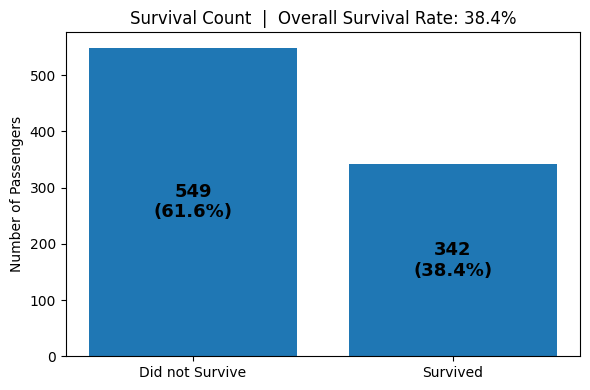

In [47]:
# ── Chart 1: Survival Count ───────────────────────────────────────────────
plt.figure(figsize=(6, 4))
surv_counts = df["Survived"].value_counts().sort_index()
total = surv_counts.sum()
bars = plt.bar(["Did not Survive", "Survived"], surv_counts.values)

labels = (surv_counts.astype(str) + "\n(" + (surv_counts / total * 100).round(1).astype(str) + "%)").values
[plt.text(bars[i].get_x() + bars[i].get_width() / 2, bars[i].get_height() / 2,
          labels[i], ha="center", va="center", fontsize=13, fontweight="bold") for i in range(len(bars))]

plt.title(f"Survival Count  |  Overall Survival Rate: {df['Survived'].mean()*100:.1f}%")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

**Insight:** Only **38.4%** of passengers survived. The majority (61.6%) did not survive the sinking.

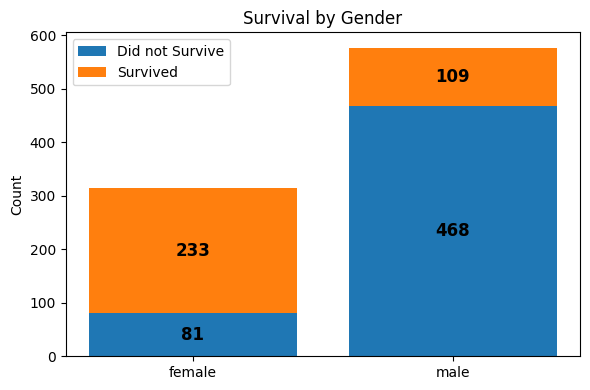

In [ ]:
# ── Chart 2: Survival by Gender ───────────────────────────────────────────────
plt.figure(figsize=(6, 4))
surv = df.groupby("Sex")["Survived"].sum()
not_surv = df.groupby("Sex")["Survived"].apply(lambda x: (x == 0).sum())

bars_no = plt.bar(surv.index, not_surv.values, label="Did not Survive")
bars_yes = plt.bar(surv.index, surv.values, bottom=not_surv.values, label="Survived")

[plt.text(bars_no[i].get_x() + bars_no[i].get_width() / 2, not_surv.values[i] / 2,
          f"{not_surv.values[i]}", ha="center", va="center", fontsize=12, fontweight="bold") for i in range(len(bars_no))]

[plt.text(bars_yes[i].get_x() + bars_yes[i].get_width() / 2, not_surv.values[i] + surv.values[i] / 2,
          f"{surv.values[i]}", ha="center", va="center", fontsize=12, fontweight="bold") for i in range(len(bars_yes))]

plt.title("Survival by Gender")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Female passengers had a more survival rate than males — reflecting the "women and children first" evacuation policy.

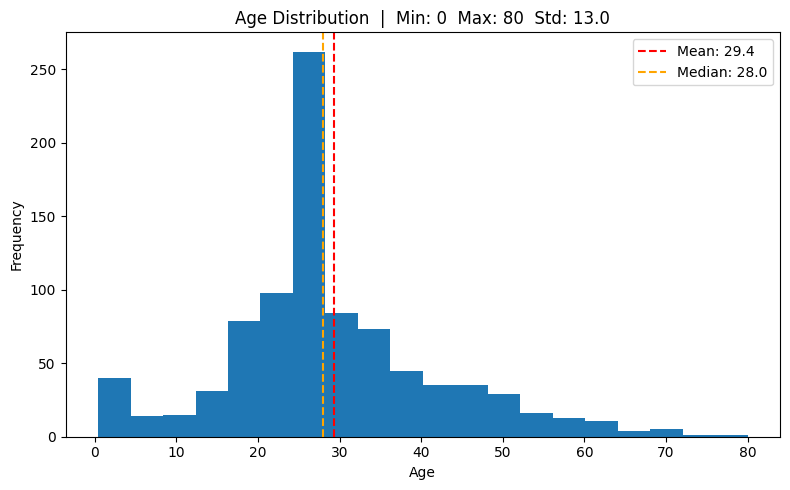

In [ ]:
# ── Chart 3: Age Distribution ───────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=20)

plt.axvline(df["Age"].mean(), color="red", linestyle="--", label=f"Mean: {df['Age'].mean():.1f}")
plt.axvline(df["Age"].median(), color="orange", linestyle="--", label=f"Median: {df['Age'].median():.1f}")

plt.title(f"Age Distribution  |  Min: {df['Age'].min():.0f}  Max: {df['Age'].max():.0f}  Std: {df['Age'].std():.1f}")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Most passengers were between **20 and 40 years old**. There is also a small spike of very young children (under 5), indicating families traveling together.

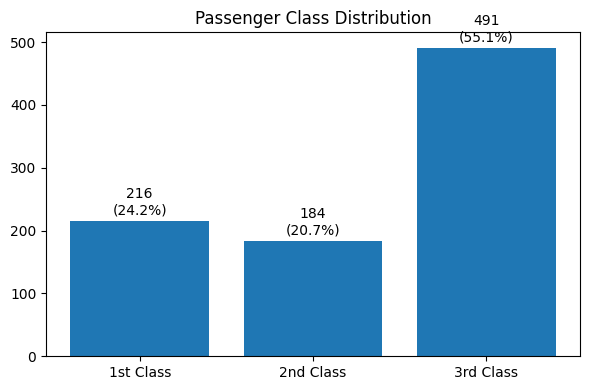

In [ ]:
# ── Chart 4: Passenger Class Distribution ─────────────────────────────────────
plt.figure(figsize=(6, 4))
class_counts = df["Pclass"].value_counts().sort_index()
total = class_counts.sum()
bars = plt.bar(["1st Class", "2nd Class", "3rd Class"], class_counts.values)

labels = (class_counts.astype(str) + "\n(" + (class_counts / total * 100).round(1).astype(str) + "%)").values
[plt.text(bars[i].get_x() + bars[i].get_width() / 2, bars[i].get_height() + 5,
          labels[i], ha="center", va="bottom") for i in range(len(bars))]

plt.title("Passenger Class Distribution")
plt.tight_layout()
plt.show()

**Insight:** **3rd class** had the most passengers, more than **1st** and **2nd** combined — yet as we'll see, **3rd** class had the lowest survival rate.

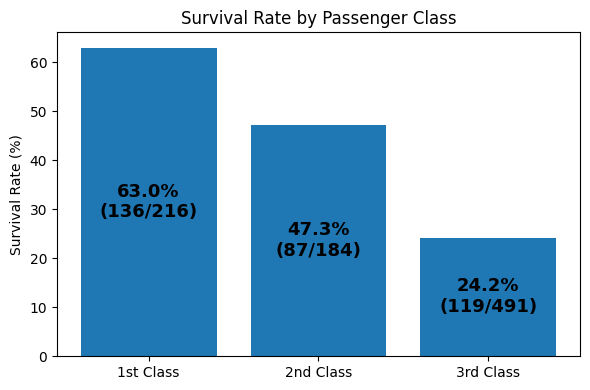

In [50]:
# ── Chart 5: Survival Rate by Passenger Class ───────────────────────────────────
surv_rate = df.groupby("Pclass")["Survived"].mean()
surv_counts = df.groupby("Pclass")["Survived"].sum()
class_totals = df.groupby("Pclass")["Survived"].count()

plt.figure(figsize=(6, 4))
bars = plt.bar(["1st Class", "2nd Class", "3rd Class"], surv_rate.values * 100)

labels = ((surv_rate * 100).round(1).astype(str) + "%\n(" + surv_counts.astype(str) + "/" + class_totals.astype(str) + ")").values
[plt.text(bars[i].get_x() + bars[i].get_width() / 2, bars[i].get_height() / 2,
          labels[i], ha="center", va="center", fontsize=13, fontweight="bold") for i in range(len(bars))]

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

**Insight:** 1st class passengers survived more often than other classes, while 3rd class passengers survived the least. This shows a clear difference between passenger classes, likely influenced by their location on the ship and access to lifeboats.

---
## 5. Simple Model (Random Forest)

5.1 Features and target 


In [34]:
# Data Preprocessing for Machine Learning
df_ml = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
df_ml = pd.get_dummies(df_ml, columns=['Sex', 'Embarked'], drop_first=True)

# Define Features (X) and Target (y)
X = df_ml.drop(columns=['Survived'])
y = df_ml['Survived']

5.2 Train/test split


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

5.3 Create model


In [36]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

5.4 Train

In [37]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

5.5 Predict

In [38]:
y_pred = model.predict(X_test)

5.6 Evaluation

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8100558659217877

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


Confusion Matrix:
[[97 13]
 [21 48]]


**Model Results — Interpretation:**

The Random Forest achieved approximately **80% accuracy** on the test set.

- **Precision** tells us how many of the predicted survivors actually survived. A precision of ~0.80 for class 1 means 80% of passengers the model labeled as survivors truly did survive.
- **Recall** tells us how many actual survivors the model correctly identified. A recall of ~0.78 means the model caught 78% of all real survivors.
- **F1-score** is the balance between the two — useful here because the classes are slightly imbalanced (~62% did not survive vs ~38% who did).


Feature importance


In [40]:
importance = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
4        Fare    0.283522
5    Sex_male    0.254065
1         Age    0.252432
0      Pclass    0.083669
2       SibSp    0.050014
3       Parch    0.040511
7  Embarked_S    0.025637
6  Embarked_Q    0.010150


**Model Results — Interpretation:**

**Feature Importances:**
- `Fare` is the most important feature (0.28), suggesting that ticket price — a proxy for wealth and cabin location — was the strongest predictor of survival.
- `Sex_male` (0.25) and `Age` (0.25) rank nearly equal in second place, confirming that gender and age were critical survival factors.
- `Pclass` (0.08) adds additional class-based signal, though much of it is already captured by `Fare`.
- `SibSp`, `Parch`, and `Embarked` have low importance, suggesting family size and port of embarkation had minimal predictive value.

---
## 6. Final Conclusion

This exploratory analysis of 891 Titanic passengers reveals clear patterns in who survived the disaster:

| Finding | Detail |
|---|---|
| Overall survival rate | 38.4% of passengers survived |
| Gender effect | Female passengers had a more survival rate than males |
| Class effect | 1st class passengers survived more often than other classes, while 3rd class passengers survived the least. |
| Age | Most passengers were 20–40 years old |
| Fare distribution | Heavily right-skewed — most paid modest fares; a few 1st-class passengers paid extremely high fares |

**Key takeaways:**

1. **Gender was the strongest predictor of survival** — the "women and children first" policy had a dramatic real-world effect.
2. **Wealth (passenger class) also strongly influenced survival** — 1st class passengers had better access to lifeboats due to their cabin locations.
3. **Data cleaning was necessary before analysis** — Age had 177 missing values, Cabin had 687 and was dropped entirely, and Embarked had 2 missing values.
4. **Simple Model:** The Random Forest classification model achieved strong predictive accuracy (approx. 80%), demonstrating that survival was not entirely random but heavily patterned by socioeconomic and demographic factors.